# Week 9 Phase 1.18B0 — FAST GPC-SUR update validation

This notebook reads a frozen validation audit. It does not generate an acquisition path.

In [1]:
from pathlib import Path
import json,pandas as pd
from IPython.display import display,Image,Markdown
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_18b0_fast_gpc_sur_update_validation'
display(json.loads((OUT/'baseline_gate.json').read_text()))

{'conduction': 332,
 'current_head': '658d5b73cf27e45b4b2e0897cff27a49a2ef4b84',
 'frozen_paths': 100,
 'historical_changes': [],
 'keyholes': 73,
 'merge_base': '658d5b73cf27e45b4b2e0897cff27a49a2ef4b84',
 'outer_runs': 100,
 'parent_sha': '658d5b73cf27e45b4b2e0897cff27a49a2ef4b84',
 'phase18a_candidate_rows': 169200,
 'population': 405,
 'status': 'PASS'}

## 1. Why four update levels?

FAST error must be separated from physics-mean refitting and kernel-hyperparameter refitting.

In [2]:
display(Markdown((OUT/'sur_literature_update_contract.md').read_text())); display(pd.read_csv(OUT/'snapshot_validation_design.csv')); display(pd.read_csv(OUT/'candidate_validation_design.csv').groupby('snapshot_id').size().describe())

# Literature-faithful SUR update contract

[Bect et al. (2012)](https://doi.org/10.1007/s11222-011-9241-4) formulate stepwise uncertainty reduction as minimizing expected future uncertainty of an excursion-set quantity under the current posterior predictive distribution. [Menz, MuÃ±oz Zuniga, and Sinoquet (2025)](https://doi.org/10.1016/j.strusafe.2025.102607) extend random-set uncertainty reduction to Gaussian-process classification.

This validation retains Phase 1.18A's finite-pool functional `U=mean_u p(u)(1-p(u))`. It is a probability-uncertainty surrogate, not asserted to be algebraically identical to every random-set functional in Menz et al. Both hypothetical labels are weighted by current `p_n(x)`. The literature-defined one-step posterior update is closest to `EXACT_LAPLACE_FIXED_MODEL`: current mean/scaler/kernel hyperparameters are held fixed while the enlarged-data Laplace posterior is solved. Refitting physics or kernel hyperparameters is a secondary empirical-Bayes model-refit effect, not automatically the theoretical acquisition definition.


,snapshot_id,run_id,repeat,fold,budget,selection_role,residual_sd,any_length_upper_bound_hit,upper_length_hit_count,anisotropy_ratio,optimizer_converged,posterior_iterations
0,w85__r06_f05__B16,w85__r06_f05,6,5,16,no_upper_hit,0.050000,False,0,1.000052,True,2
1,w85__r16_f04__B16,w85__r16_f04,16,4,16,upper_bound_pressure,1.000000,True,3,4731.091451,True,5
2,w85__r02_f03__B16,w85__r02_f03,2,3,16,high_residual_sd,1.000000,True,2,144.867731,True,5
3,w85__r01_f02__B16,w85__r01_f02,1,2,16,low_residual_sd,0.050000,False,0,1.000452,True,2
4,w85__r12_f05__B16,w85__r12_f05,12,5,16,ordinary_median_anisotropy,0.050000,False,0,1.002640,True,2
5,w85__r04_f01__B24,w85__r04_f01,4,1,24,no_upper_hit,0.050000,False,0,1.001812,True,3
6,w85__r09_f03__B24,w85__r09_f03,9,3,24,upper_bound_pressure,0.894024,True,3,10000.000000,True,5
7,w85__r01_f02__B24,w85__r01_f02,1,2,24,high_residual_sd,1.000000,True,3,257.752164,True,5
8,w85__r01_f05__B24,w85__r01_f05,1,5,24,low_residual_sd,0.050000,True,2,343.372239,True,3
9,w85__r06_f02__B24,w85__r06_f02,6,2,24,ordinary_median_anisotropy,1.000000,True,2,289.301471,True,5


count    25.000000
mean     12.280000
std       0.541603
min      12.000000
25%      12.000000
50%      12.000000
75%      12.000000
max      14.000000
dtype: float64

## 2. Probability and algebra gates

In [3]:
display(pd.read_csv(OUT/'probability_integration_validation.csv').sort_values('absolute_error',ascending=False).head()); display(pd.read_csv(OUT/'special_case_validation.csv'))

,mu,variance,gauss_hermite_100,m3_williams_barber,absolute_error
36,6.0,0.000001,0.997527,0.997121,0.000406
0,-6.0,0.000001,0.002473,0.002879,0.000406
37,6.0,0.010000,0.997515,0.997111,0.000404
1,-6.0,0.010000,0.002485,0.002889,0.000404
38,6.0,0.100000,0.997402,0.997021,0.000380


,case,max_mean_change,max_variance_change,status
0,zero_cross_covariance,0.000000e+00,0.000000e+00,PASS
1,same_point_variance,NaN,0.000000e+00,PASS
2,low_curvature_limit_expected_update,1.387779e-17,4.440892e-16,PASS
3,near_zero_variance,4.801715e-15,9.900000e-13,PASS


## 3. Primary score and selection fidelity

,snapshots,median_spearman,q10_spearman,median_kendall_tau,median_pearson,top1_agreement,mean_top3_jaccard,mean_top5_jaccard,mean_top10_jaccard,median_fast_top_rank_under_exact,sign_reversal_fraction,late_median_spearman
0,25,0.481319,-0.21062,0.384615,0.432298,0.44,0.44,0.52381,0.725221,2.0,0.286645,0.474925


,snapshot_id,budget,top1_agreement,top3_jaccard,top5_jaccard,top10_jaccard,fast_top_rank_under_exact,exact_top_rank_under_fast
0,w85__r01_f01__B80,80,0.0,0.2,0.428571,0.818182,4.0,6.0
1,w85__r01_f02__B16,16,1.0,1.0,1.000000,0.818182,1.0,1.0
2,w85__r01_f02__B24,24,1.0,0.5,0.250000,0.666667,1.0,1.0
3,w85__r01_f02__B40,40,1.0,0.2,0.428571,0.538462,1.0,1.0
4,w85__r01_f02__B60,60,0.0,0.5,0.666667,0.818182,3.0,14.0
5,w85__r01_f05__B24,24,0.0,0.5,1.000000,0.666667,3.0,2.0
6,w85__r01_f05__B60,60,0.0,0.2,0.111111,0.666667,9.0,3.0
7,w85__r02_f03__B16,16,0.0,0.5,1.000000,0.538462,2.0,3.0
8,w85__r02_f04__B60,60,0.0,0.0,0.000000,0.538462,13.0,8.0
9,w85__r04_f01__B24,24,0.0,0.2,0.428571,0.818182,3.0,1.0


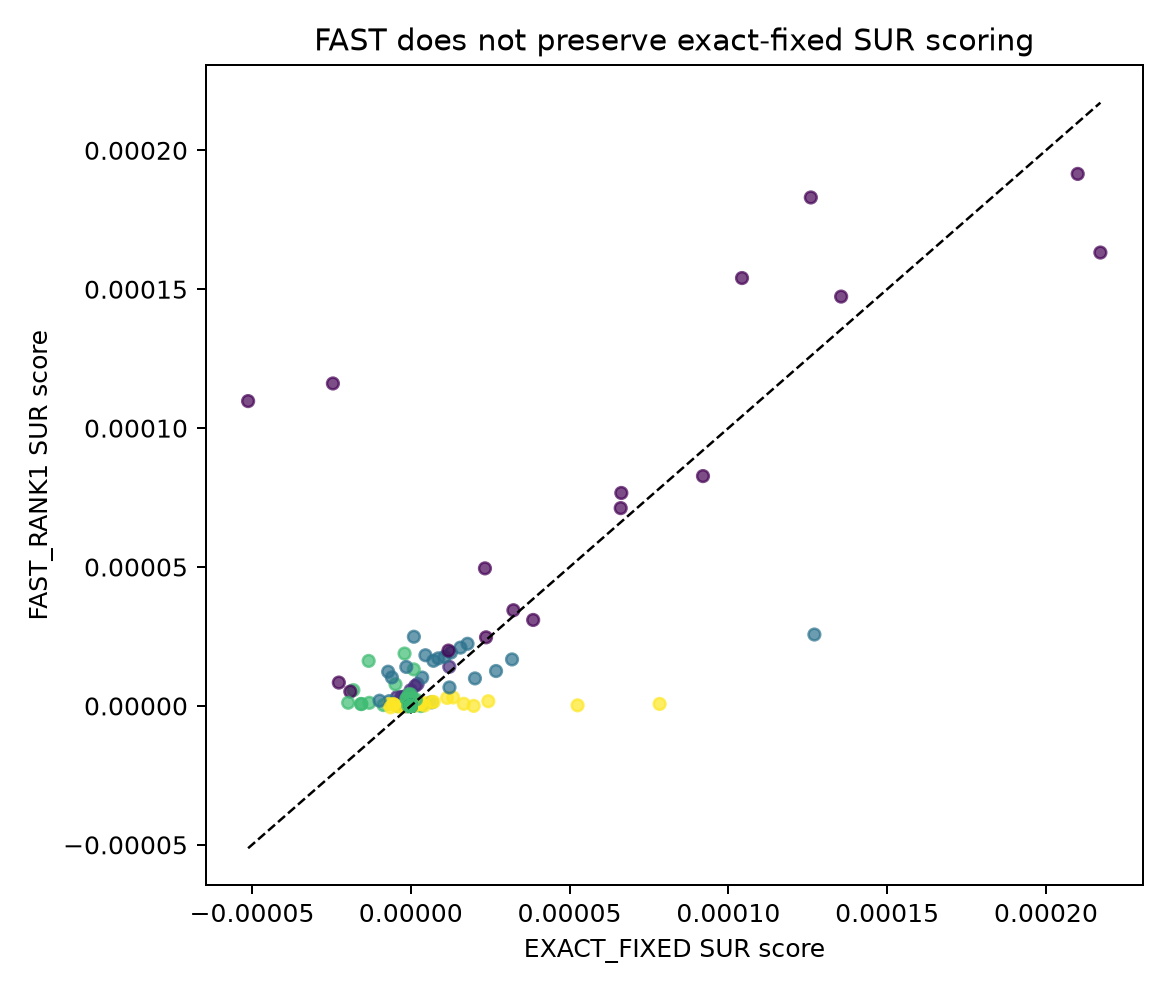

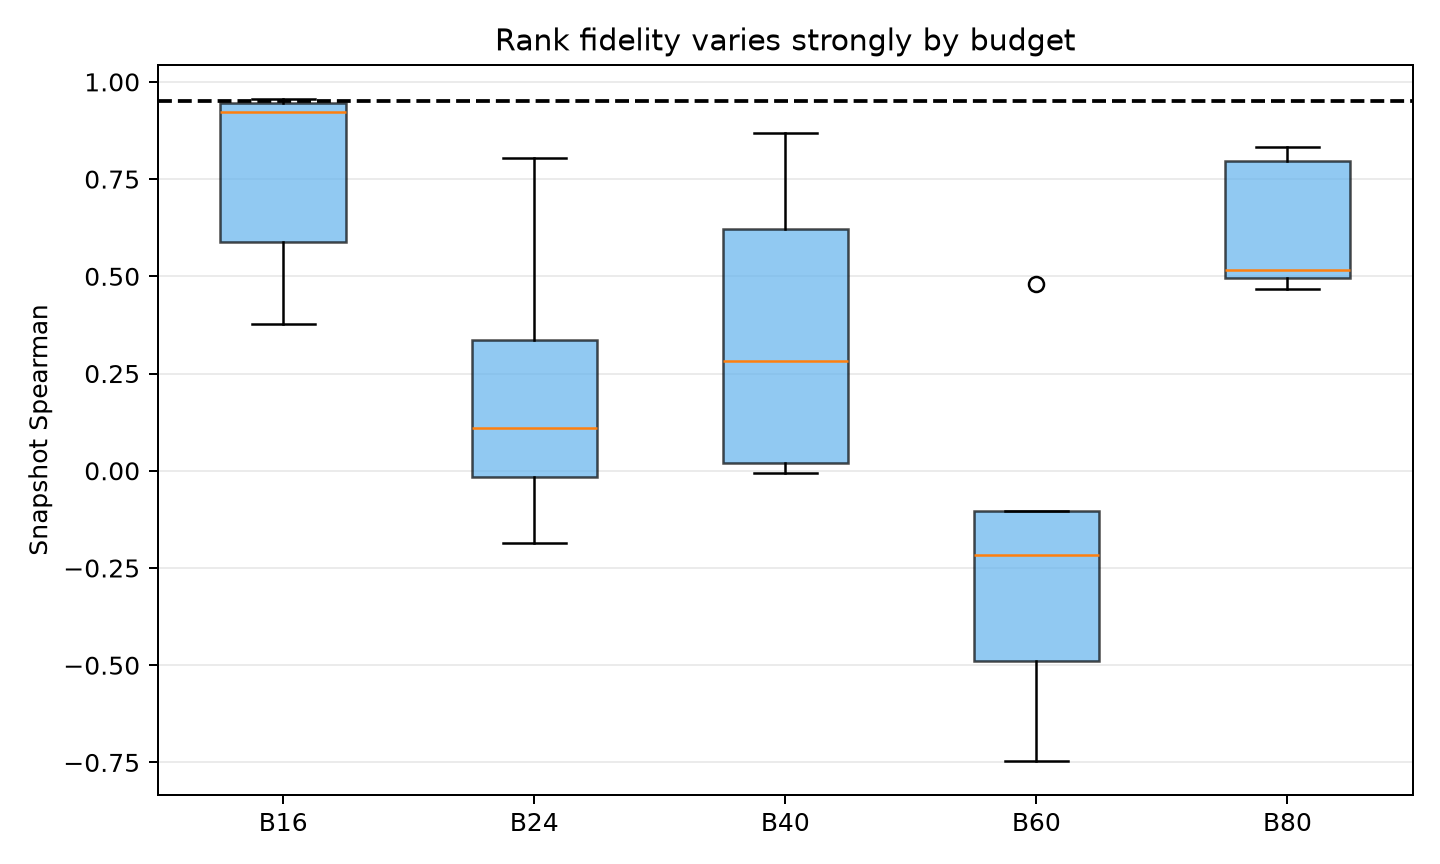

In [4]:
display(pd.read_csv(OUT/'sur_score_fidelity_overall.csv')); display(pd.read_csv(OUT/'selection_fidelity_summary.csv')); display(Image(filename=str(OUT/'figures'/'01_fast_vs_exact_sur_scatter.png'))); display(Image(filename=str(OUT/'figures'/'02_snapshot_spearman_by_budget.png')))

## 4. Posterior fidelity

Small probability error does not guarantee fidelity of a difference-of-uncertainties acquisition score.

,snapshot_id,probability_mae,probability_q95,probability_max,latent_mean_mae,latent_variance_mae,budget
0,w85__r01_f01__B80,2.144688e-04,1.083695e-03,1.539024e-02,1.319305e-02,1.754291e-03,80
1,w85__r01_f02__B16,1.063248e-10,4.005198e-11,5.340826e-08,6.239845e-09,1.146373e-11,16
2,w85__r01_f02__B24,1.384547e-05,1.692409e-07,7.186312e-03,3.037947e-03,3.115695e-03,24
3,w85__r01_f02__B40,1.109534e-04,5.069929e-04,9.147869e-03,5.173375e-03,1.538439e-03,40
4,w85__r01_f02__B60,5.011659e-05,2.088598e-04,6.024292e-03,1.086607e-02,3.102527e-03,60
5,w85__r01_f05__B24,3.493886e-10,9.506081e-10,5.333797e-08,9.269747e-09,2.811210e-11,24
6,w85__r01_f05__B60,1.062269e-05,3.876843e-08,4.905118e-03,1.967425e-04,1.895177e-04,60
7,w85__r02_f03__B16,1.669120e-04,8.279964e-04,5.591381e-03,2.263847e-03,1.854615e-03,16
8,w85__r02_f04__B60,1.456092e-05,6.723596e-05,1.804138e-03,1.149319e-03,1.611565e-03,60
9,w85__r04_f01__B24,1.043147e-15,0.000000e+00,1.137979e-13,5.235471e-13,2.730584e-13,24


,hypothetical_label,probability_mae,probability_q95,latent_variance_mae
0,0,0.000020,0.000038,0.000457
1,1,0.000045,0.000153,0.001106


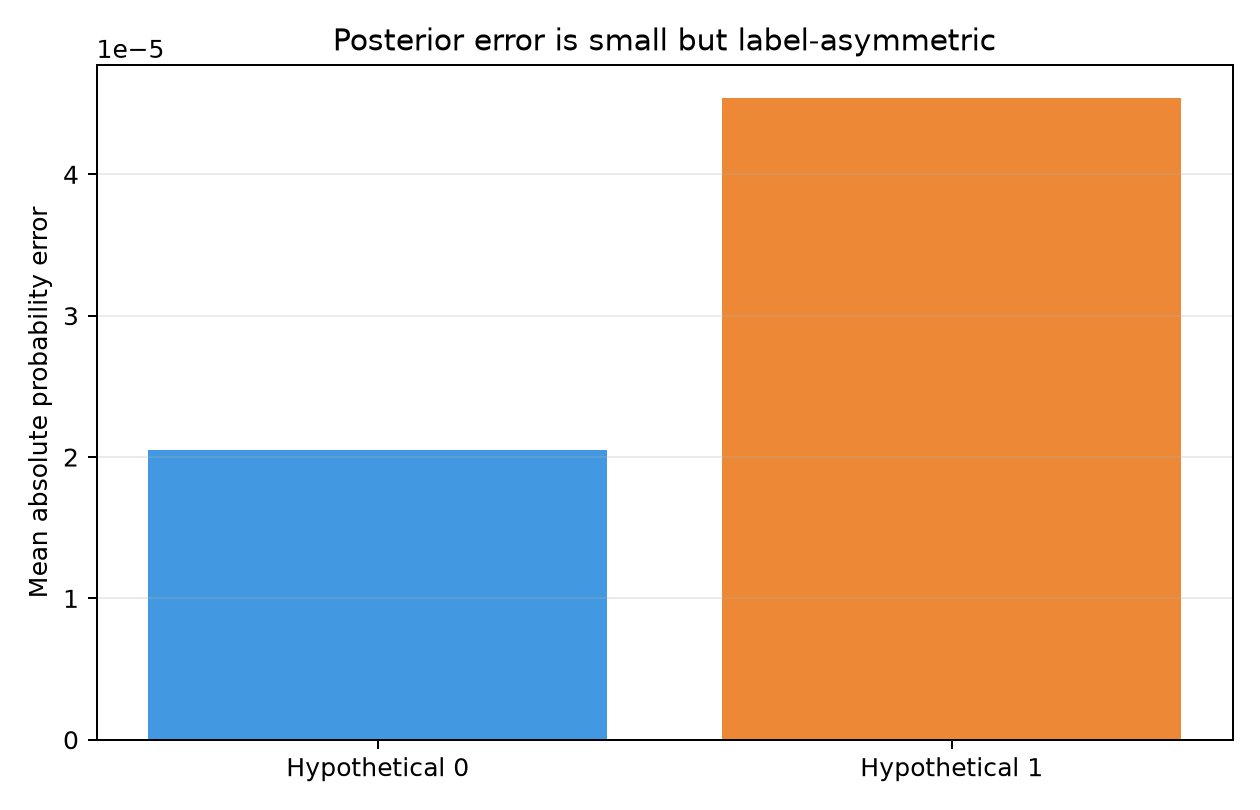

In [5]:
display(pd.read_csv(OUT/'posterior_fidelity_summary.csv')); display(pd.read_csv(OUT/'label_conditional_fidelity.csv')); display(Image(filename=str(OUT/'figures'/'04_probability_error_by_label.png')))

## 5. Refit-effect decomposition

,spearman,top1_agreement,top5_jaccard
effect,,,
hyperparameter_refit_effect,0.986014,0.64,0.776508
physics_refit_effect,0.262697,0.08,0.412222
rank_one_error,0.481319,0.44,0.523810


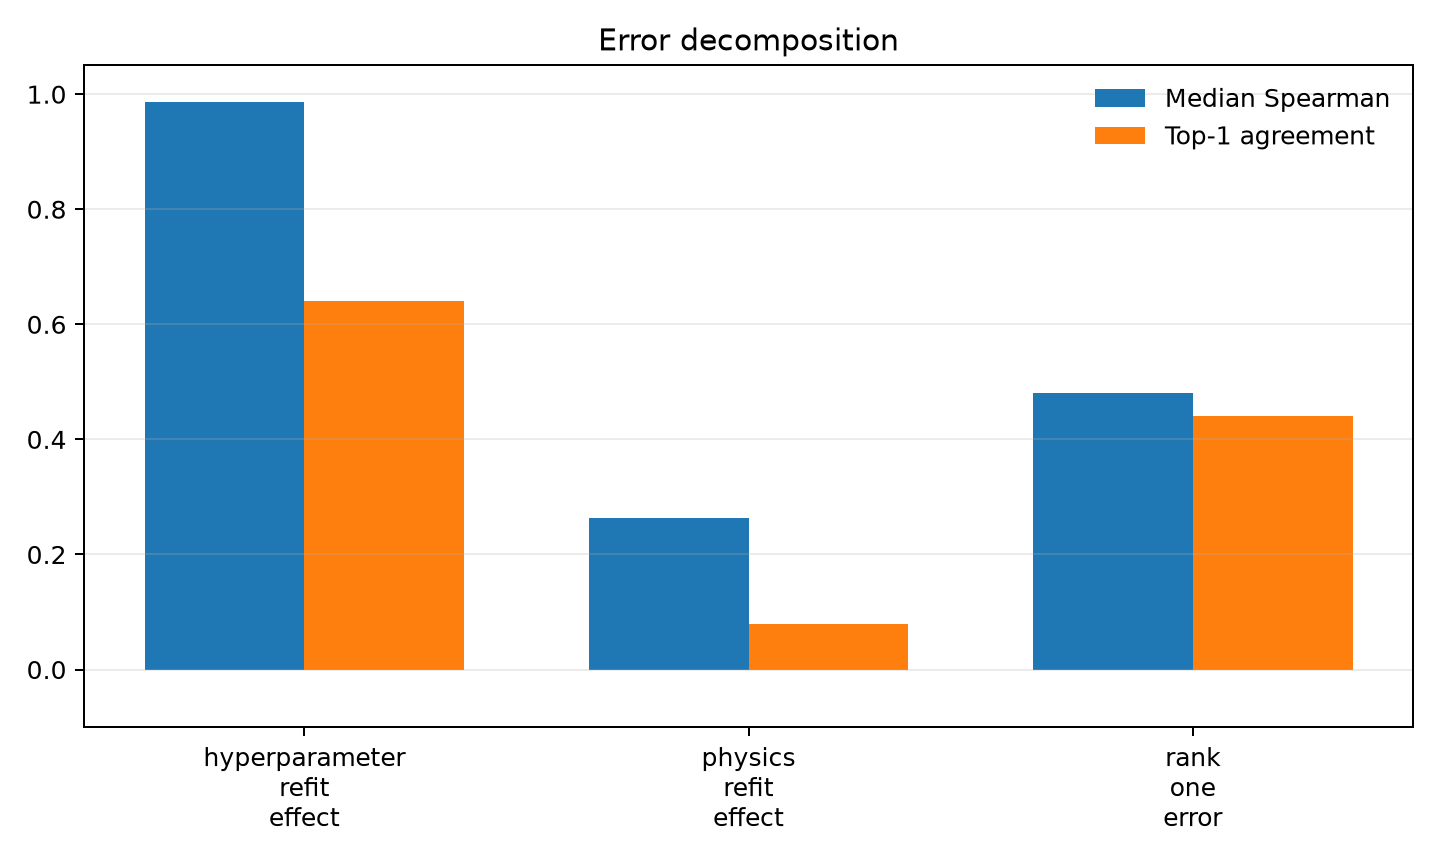

In [6]:
display(pd.read_csv(OUT/'refit_effect_decomposition.csv').groupby('effect').agg({'spearman':'median','top1_agreement':'mean','top5_jaccard':'mean'})); display(Image(filename=str(OUT/'figures'/'05_refit_effect_decomposition.png')))

## 6. Decision

In [7]:
display(json.loads((OUT/'primary_decision.json').read_text())); display(json.loads((OUT/'refit_effect_decision.json').read_text())); display(Markdown((OUT/'SUPERVISOR_PHASE1_18B0_ONE_PAGE.md').read_text()))

{'criteria': {'late_median_spearman': False,
  'mean_top5_jaccard': False,
  'median_fast_top_rank_under_exact': True,
  'median_probability_mae': True,
  'median_spearman': False,
  'q10_spearman': False,
  'q90_snapshot_probability_mae': True,
  'sign_reversal_fraction': False,
  'top1_agreement': False},
 'decision': 'FAST_SUR_REJECTED',
 'gate': {'late_median_spearman': 0.85,
  'mean_top5_jaccard': 0.7,
  'median_fast_top_rank_under_exact': 2.0,
  'median_posterior_probability_mae': 0.02,
  'median_spearman': 0.95,
  'q10_spearman': 0.8,
  'q90_snapshot_probability_mae': 0.05,
  'sign_reversal_fraction': 0.05,
  'top1_agreement': 0.7},
 'guarded_prospective_possible': False,
 'observed': {'late_median_spearman': 0.47492507492507496,
  'mean_top10_jaccard': 0.7252214452214453,
  'mean_top3_jaccard': 0.43999999999999995,
  'mean_top5_jaccard': 0.5238095238095238,
  'median_fast_top_rank_under_exact': 2.0,
  'median_kendall_tau': 0.3846153846153845,
  'median_pearson': 0.4322976121991

{'decision': 'PHYSICS_REFIT_MATTERS',
 'predeclared_matters_rule': 'median Spearman <0.90 or top-1 agreement <0.60',
 'summary': [{'effect': 'hyperparameter_refit_effect',
   'mean_top5_jaccard': 0.7765079365079365,
   'median_spearman': 0.9860139860139862,
   'top1_agreement': 0.64},
  {'effect': 'physics_refit_effect',
   'mean_top5_jaccard': 0.4122222222222222,
   'median_spearman': 0.26269742562687987,
   'top1_agreement': 0.08},
  {'effect': 'rank_one_error',
   'mean_top5_jaccard': 0.5238095238095238,
   'median_spearman': 0.4813186813186813,
   'top1_agreement': 0.44}]}

# Supervisor Phase 1.18B0 â€” one page

- 25 frozen snapshots, 307 candidates, 2,456 hypothetical-label/update-level calculations; no new path.
- FAST vs exact-fixed: median Spearman **0.481**, q10 **-0.211**, top-1 **44%**, top-5 Jaccard **0.524**; 2/25 correlations undefined for constant score vectors.
- Posterior probability MAE is tiny (median snapshot 1.06e-05), yet SUR rankings fail because the acquisition score is a small difference of global uncertainties.
- Hypothetical Keyhole updates have larger error than Conduction (4.54e-05 vs 2.05e-05).
- Physics-mean refitting matters strongly (median score Spearman 0.263); kernel reoptimization matters much less (0.986).
- **Decision: FAST_SUR_REJECTED / PHYSICS_REFIT_MATTERS.** Do not run FAST SUR prospectively. No SUR-vs-Margin performance claim was tested.
